In [1]:
!pip -q install alns==7.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 1.9 MB/s eta 0:00:00


In [2]:
import math
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import requests

from alns import ALNS
from alns.accept import SimulatedAnnealing
from alns.select import RouletteWheel
from alns.stop import MaxIterations

In [21]:
JSON_URL = (
    "https://raw.githubusercontent.com/ceche1212/los_movimientos/"
    "refs/heads/main/data/los_movimientos_large_rest_instance.json"
)

response = requests.get(JSON_URL, timeout=30)
response.raise_for_status()
instance = response.json()

print("Instance loaded successfully")
print(f"Name: {instance['instance_name']}")
print(f"Vehicles: {len(instance['vehicles'])}")
print(f"Requests: {len(instance['requests'])}")
print(f"Service nodes: {2 * len(instance['requests'])}")

Instance loaded successfully
Name: los_movimientos_personnel_large_rest
Vehicles: 6
Requests: 24
Service nodes: 48


In [22]:
vehicles = [v["id"] for v in instance["vehicles"]]
request_ids = [r["id"] for r in instance["requests"]]

vehicle_record = {v["id"]: v for v in instance["vehicles"]}
request_record = {r["id"]: r for r in instance["requests"]}

pickup_node = {
    r: request_record[r]["pickup"]["node_id"]
    for r in request_ids
}

delivery_node = {
    r: request_record[r]["delivery"]["node_id"]
    for r in request_ids
}

passengers = {
    r: request_record[r]["passengers"]
    for r in request_ids
}

compatible_vehicles = {
    r: request_record[r].get("compatible_vehicles", vehicles.copy())
    for r in request_ids
}


node_location = {}
earliest = {}
latest = {}
service_time = {}
load_change = {}
node_type = {}
node_request = {}

for request_id in request_ids:
    request = request_record[request_id]

    for data, kind, sign in (
        (request["pickup"], "pickup", 1),
        (request["delivery"], "delivery", -1),
    ):
        node = data["node_id"]

        node_location[node] = data["location"]
        earliest[node], latest[node] = data["time_window"]
        service_time[node] = data["service_time"]
        load_change[node] = sign * request["passengers"]
        node_type[node] = kind
        node_request[node] = request_id


capacity = {
    k: vehicle_record[k]["capacity_passengers"]
    for k in vehicles
}

start_time = {
    k: vehicle_record[k]["start_time"]
    for k in vehicles
}

end_time = {
    k: vehicle_record[k]["end_time"]
    for k in vehicles
}

start_location = {
    k: vehicle_record[k]["start_location"]
    for k in vehicles
}

end_location = {
    k: vehicle_record[k]["end_location"]
    for k in vehicles
}

travel_time = instance["travel_time_minutes"]
distance = instance["distance_km"]
coordinates = instance["locations"]


def minutes_to_clock(minutes):
    minutes = int(round(minutes))
    return f"{minutes // 60:02d}:{minutes % 60:02d}"


longest_leg = max(
    value
    for row in travel_time.values()
    for value in row.values()
)

print(f"Longest direct driving leg: {longest_leg} minutes")

Longest direct driving leg: 259 minutes


In [23]:
MAX_CONTINUOUS_DRIVING = 120
BREAK_DURATION = 15
MIN_STOP_DURATION = 15

DISTANCE_WEIGHT = 1.0
DURATION_WEIGHT = 0.05
UNSERVED_PENALTY = 10_000.0

INFEASIBLE_COST = 1e12
DESTRUCTION_RATE = 0.30


def required_breaks(driving_minutes):
    if driving_minutes <= 0:
        return 0

    return max(
        0,
        math.ceil(
            driving_minutes / MAX_CONTINUOUS_DRIVING
        ) - 1
    )


def effective_travel_time(driving_minutes):
    return (
        driving_minutes
        + BREAK_DURATION * required_breaks(driving_minutes)
    )


def break_intervals(departure_time, driving_minutes):
    intervals = []

    for number in range(
        1,
        required_breaks(driving_minutes) + 1
    ):
        break_start = (
            departure_time
            + number * MAX_CONTINUOUS_DRIVING
            + (number - 1) * BREAK_DURATION
        )

        intervals.append(
            (break_start, break_start + BREAK_DURATION)
        )

    return intervals

In [24]:
for driving in [120, 121, 240, 241, 370]:
    print(
        f"{driving:>3} minutes of driving → "
        f"{required_breaks(driving)} break(s) → "
        f"{effective_travel_time(driving)} effective minutes"
    )

120 minutes of driving → 0 break(s) → 120 effective minutes
121 minutes of driving → 1 break(s) → 136 effective minutes
240 minutes of driving → 1 break(s) → 255 effective minutes
241 minutes of driving → 2 break(s) → 271 effective minutes
370 minutes of driving → 3 break(s) → 415 effective minutes


In [25]:
@lru_cache(maxsize=None)
def evaluate_route(vehicle_id, route_tuple):
    route = list(route_tuple)

    current_time = start_time[vehicle_id]
    current_load = 0

    total_distance = 0.0
    total_driving = 0
    total_breaks = 0

    previous_location = start_location[vehicle_id]

    active_requests = set()
    completed_requests = set()
    events = []

    index = 0

    while index < len(route):
        location = node_location[route[index]]

        leg_departure = current_time
        driving = travel_time[previous_location][location]
        breaks = required_breaks(driving)

        arrival = (
            leg_departure
            + effective_travel_time(driving)
        )

        total_distance += distance[
            previous_location
        ][
            location
        ]

        total_driving += driving
        total_breaks += breaks

        stop_events = []

        # Process consecutive nodes at the same physical location
        while (
            index < len(route)
            and node_location[route[index]] == location
        ):
            node = route[index]
            request_id = node_request[node]

            if vehicle_id not in compatible_vehicles[request_id]:
                return None

            previous_service_end = (
                arrival
                if not stop_events
                else stop_events[-1]["service_end"]
            )

            service_start = max(
                previous_service_end,
                earliest[node]
            )

            if service_start > latest[node]:
                return None

            # Explicit pickup-before-delivery check
            if node_type[node] == "pickup":
                if (
                    request_id in active_requests
                    or request_id in completed_requests
                ):
                    return None

                active_requests.add(request_id)

            else:
                if request_id not in active_requests:
                    return None

                active_requests.remove(request_id)
                completed_requests.add(request_id)

            current_load += load_change[node]

            if not 0 <= current_load <= capacity[vehicle_id]:
                return None

            service_end = (
                service_start
                + service_time[node]
            )

            stop_events.append({
                "node": node,
                "location": location,
                "arrival": arrival,
                "service_start": service_start,
                "service_end": service_end,
                "load": current_load,
                "leg_departure": leg_departure,
                "driving_before": (
                    driving if not stop_events else 0
                ),
                "breaks_before": (
                    breaks if not stop_events else 0
                ),
            })

            index += 1

        # The complete physical stop must last at least 15 minutes
        departure = max(
            stop_events[-1]["service_end"],
            arrival + MIN_STOP_DURATION
        )

        for event in stop_events:
            event["stop_departure"] = departure

        events.extend(stop_events)

        current_time = departure
        previous_location = location

    # Return to the vehicle's end terminal
    end_leg_departure = current_time

    driving = travel_time[
        previous_location
    ][
        end_location[vehicle_id]
    ]

    breaks = required_breaks(driving)

    finish_time = (
        end_leg_departure
        + effective_travel_time(driving)
    )

    total_distance += distance[
        previous_location
    ][
        end_location[vehicle_id]
    ]

    total_driving += driving
    total_breaks += breaks

    if (
        finish_time > end_time[vehicle_id]
        or current_load != 0
        or active_requests
    ):
        return None

    duration = finish_time - start_time[vehicle_id]

    return {
        "distance": total_distance,
        "duration": duration,
        "driving_time": total_driving,
        "finish_time": finish_time,
        "breaks": total_breaks,
        "cost": (
            DISTANCE_WEIGHT * total_distance
            + DURATION_WEIGHT * duration
        ),
        "events": events,
        "end_leg_departure": end_leg_departure,
        "end_leg_driving": driving,
        "end_leg_breaks": breaks,
    }

In [26]:
class MovementsState:

    def __init__(self, routes, unassigned=None):
        self.routes = {
            k: list(routes.get(k, []))
            for k in vehicles
        }

        self.unassigned = list(
            unassigned or []
        )

    def copy(self):
        return MovementsState(
            self.routes,
            self.unassigned
        )

    def objective(self):
        served = [
            node_request[node]
            for route in self.routes.values()
            for node in route
            if node_type[node] == "pickup"
        ]

        expected_served = (
            set(request_ids)
            - set(self.unassigned)
        )

        # Protect the search from inconsistent states
        if (
            len(served) != len(set(served))
            or set(served) != expected_served
        ):
            return INFEASIBLE_COST

        total = (
            UNSERVED_PENALTY
            * len(self.unassigned)
        )

        for k in vehicles:
            evaluation = evaluate_route(
                k,
                tuple(self.routes[k])
            )

            if evaluation is None:
                return INFEASIBLE_COST

            total += evaluation["cost"]

        return total

    @property
    def cost(self):
        return self.objective()

    def served_requests(self):
        visited_nodes = {
            node
            for route in self.routes.values()
            for node in route
        }

        return [
            r
            for r in request_ids
            if pickup_node[r] in visited_nodes
        ]

    def vehicle_of(self, request_id):
        pickup = pickup_node[request_id]

        return next(
            (
                k
                for k in vehicles
                if pickup in self.routes[k]
            ),
            None
        )

In [27]:
def remove_request(state, request_id):
    vehicle_id = state.vehicle_of(request_id)

    if vehicle_id is not None:
        state.routes[vehicle_id] = [
            node
            for node in state.routes[vehicle_id]
            if node_request[node] != request_id
        ]

    if request_id not in state.unassigned:
        state.unassigned.append(request_id)


def insertion_options(state, request_id):
    pickup = pickup_node[request_id]
    delivery = delivery_node[request_id]

    options = []

    for k in compatible_vehicles[request_id]:
        route = state.routes[k]

        base_evaluation = evaluate_route(
            k,
            tuple(route)
        )

        if base_evaluation is None:
            continue

        for pickup_position in range(
            len(route) + 1
        ):
            route_with_pickup = (
                route[:pickup_position]
                + [pickup]
                + route[pickup_position:]
            )

            for delivery_position in range(
                pickup_position + 1,
                len(route_with_pickup) + 1
            ):
                candidate = (
                    route_with_pickup[:delivery_position]
                    + [delivery]
                    + route_with_pickup[delivery_position:]
                )

                evaluation = evaluate_route(
                    k,
                    tuple(candidate)
                )

                if evaluation is None:
                    continue

                additional_cost = (
                    evaluation["cost"]
                    - base_evaluation["cost"]
                )

                options.append(
                    (
                        additional_cost,
                        k,
                        candidate
                    )
                )

    return sorted(
        options,
        key=lambda option: option[0]
    )


def number_to_remove(state):
    served_count = len(
        state.served_requests()
    )

    return min(
        served_count,
        max(
            1,
            math.ceil(
                DESTRUCTION_RATE * served_count
            )
        )
    )

In [28]:
def random_removal(current, rng):
    destroyed = current.copy()
    served = destroyed.served_requests()
    q = number_to_remove(destroyed)

    if q:
        selected = rng.choice(
            served,
            size=q,
            replace=False
        )

        for request_id in selected:
            remove_request(
                destroyed,
                str(request_id)
            )

    return destroyed

In [29]:
def removal_saving(state, request_id):
    k = state.vehicle_of(request_id)

    if k is None:
        return -math.inf

    old_evaluation = evaluate_route(
        k,
        tuple(state.routes[k])
    )

    candidate_route = [
        node
        for node in state.routes[k]
        if node_request[node] != request_id
    ]

    new_evaluation = evaluate_route(
        k,
        tuple(candidate_route)
    )

    return (
        old_evaluation["cost"]
        - new_evaluation["cost"]
    )


def worst_removal(current, rng):
    destroyed = current.copy()
    q = number_to_remove(destroyed)

    for _ in range(q):
        served = destroyed.served_requests()

        if not served:
            break

        request_id = max(
            served,
            key=lambda r: (
                removal_saving(destroyed, r)
                + 1e-6 * rng.random()
            )
        )

        remove_request(
            destroyed,
            request_id
        )

    return destroyed

In [30]:
MAX_DISTANCE = max(
    value
    for row in distance.values()
    for value in row.values()
)

HORIZON = (
    instance["planning_horizon"]["end"]
    - instance["planning_horizon"]["start"]
)

MAX_PASSENGERS = max(
    passengers.values()
)


def relatedness(first, second):
    p1 = pickup_node[first]
    p2 = pickup_node[second]

    d1 = delivery_node[first]
    d2 = delivery_node[second]

    spatial = (
        distance[
            node_location[p1]
        ][
            node_location[p2]
        ]
        +
        distance[
            node_location[d1]
        ][
            node_location[d2]
        ]
    ) / (2 * MAX_DISTANCE)

    temporal = (
        abs(earliest[p1] - earliest[p2])
        + abs(earliest[d1] - earliest[d2])
    ) / (2 * HORIZON)

    demand = (
        abs(
            passengers[first]
            - passengers[second]
        )
        / MAX_PASSENGERS
    )

    return spatial + temporal + demand


def related_removal(current, rng):
    destroyed = current.copy()
    served = destroyed.served_requests()
    q = number_to_remove(destroyed)

    if not served:
        return destroyed

    seed = str(
        rng.choice(served)
    )

    candidates = [
        request_id
        for request_id in served
        if request_id != seed
    ]

    candidates.sort(
        key=lambda request_id: (
            relatedness(seed, request_id)
            + 0.05 * rng.random()
        )
    )

    selected = (
        [seed]
        + candidates[:q - 1]
    )

    for request_id in selected:
        remove_request(
            destroyed,
            request_id
        )

    return destroyed

In [31]:
def greedy_repair(destroyed, rng):
    repaired = destroyed.copy()

    while repaired.unassigned:
        candidates = []

        for request_id in repaired.unassigned:
            options = insertion_options(
                repaired,
                request_id
            )

            if options:
                delta, k, route = options[0]

                candidates.append(
                    (
                        delta,
                        rng.random(),
                        request_id,
                        k,
                        route
                    )
                )

        if not candidates:
            break

        _, _, request_id, k, route = min(
            candidates,
            key=lambda item: (
                item[0],
                item[1]
            )
        )

        repaired.routes[k] = route
        repaired.unassigned.remove(request_id)

    return repaired

In [32]:
def regret_2_repair(destroyed, rng):
    repaired = destroyed.copy()

    while repaired.unassigned:
        choices = []

        for request_id in repaired.unassigned:
            options = insertion_options(
                repaired,
                request_id
            )

            if not options:
                continue

            if len(options) > 1:
                regret = (
                    options[1][0]
                    - options[0][0]
                )
            else:
                regret = 1e6

            delta, k, route = options[0]

            choices.append(
                (
                    regret,
                    -delta,
                    rng.random(),
                    request_id,
                    k,
                    route
                )
            )

        if not choices:
            break

        (
            _,
            _,
            _,
            request_id,
            k,
            route
        ) = max(
            choices,
            key=lambda item: (
                item[0],
                item[1],
                item[2]
            )
        )

        repaired.routes[k] = route
        repaired.unassigned.remove(request_id)

    return repaired

In [33]:
SEED = 42

initial_rng = np.random.default_rng(
    SEED
)

empty_state = MovementsState(
    routes={
        k: []
        for k in vehicles
    },
    unassigned=request_ids
)

initial_solution = greedy_repair(
    empty_state,
    initial_rng
)

print(
    f"Initial objective: "
    f"{initial_solution.objective():.2f}"
)

print(
    "Initially unserved requests:",
    initial_solution.unassigned
)

Initial objective: 11859.65
Initially unserved requests: ['R12']


In [34]:
ITERATIONS = 5_000

alns = ALNS(
    np.random.default_rng(SEED)
)

alns.add_destroy_operator(
    random_removal,
    name="Random removal"
)

alns.add_destroy_operator(
    worst_removal,
    name="Worst removal"
)

alns.add_destroy_operator(
    related_removal,
    name="Related removal"
)

alns.add_repair_operator(
    greedy_repair,
    name="Greedy insertion"
)

alns.add_repair_operator(
    regret_2_repair,
    name="Regret-2 insertion"
)


selection = RouletteWheel(
    scores=[25, 5, 1, 0],
    decay=0.8,
    num_destroy=len(
        alns.destroy_operators
    ),
    num_repair=len(
        alns.repair_operators
    )
)

acceptance = SimulatedAnnealing.autofit(
    init_obj=initial_solution.objective(),
    worse=0.05,
    accept_prob=0.50,
    num_iters=ITERATIONS
)

stopping = MaxIterations(
    ITERATIONS
)


result = alns.iterate(
    initial_solution,
    selection,
    acceptance,
    stopping
)

best_solution = result.best_state

In [35]:
total_distance = 0
total_duration = 0
total_driving = 0
total_breaks = 0

for k in vehicles:
    evaluation = evaluate_route(
        k,
        tuple(best_solution.routes[k])
    )

    total_distance += evaluation["distance"]
    total_duration += evaluation["duration"]
    total_driving += evaluation["driving_time"]
    total_breaks += evaluation["breaks"]


print("ALNS search completed")
print(
    f"\nInitial objective: "
    f"{initial_solution.objective():.2f}"
)
print(
    f"Best objective: "
    f"{best_solution.objective():.2f}"
)
print(
    f"Total distance: "
    f"{total_distance:.1f} km"
)
print(
    f"Total vehicle duration: "
    f"{total_duration:.0f} minutes"
)
print(
    f"Total driving time: "
    f"{total_driving:.0f} minutes"
)
print(
    f"Mandatory roadside breaks: "
    f"{total_breaks}"
)
print(
    f"Unserved requests: "
    f"{len(best_solution.unassigned)}"
)

if best_solution.unassigned:
    print(
        "Requests in the request bank:",
        best_solution.unassigned
    )
else:
    print(
        "All transportation requests were served."
    )

ALNS search completed

Initial objective: 11859.65
Best objective: 1738.75
Total distance: 1580.4 km
Total vehicle duration: 3167 minutes
Total driving time: 2502 minutes
Mandatory roadside breaks: 6
Unserved requests: 0
All transportation requests were served.


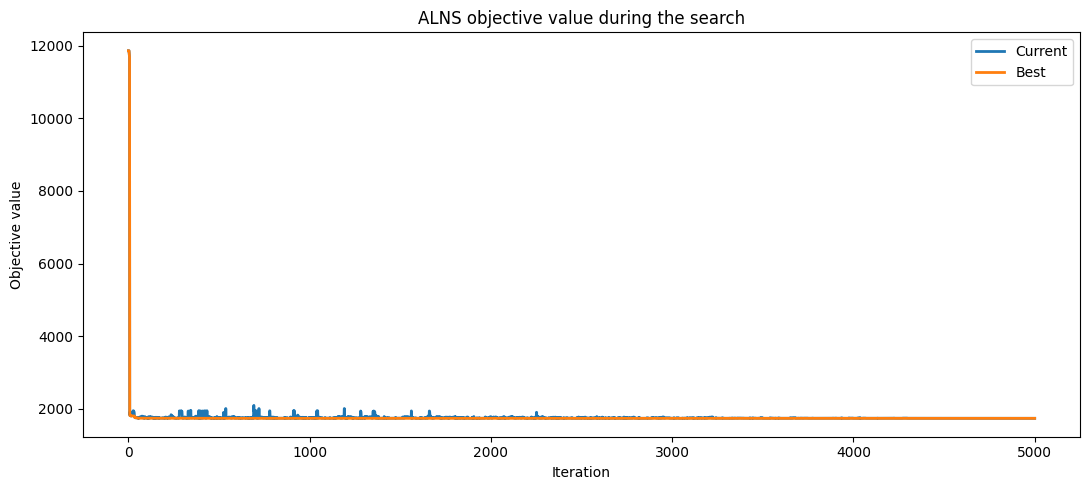

In [36]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

result.plot_objectives(
    ax=ax,
    lw=2
)

ax.set_title(
    "ALNS objective value during the search"
)

ax.set_xlabel(
    "Iteration"
)

ax.set_ylabel(
    "Objective value"
)

plt.tight_layout()
plt.show()

In [39]:
for k in vehicles:
    route = best_solution.routes[k]

    evaluation = evaluate_route(
        k,
        tuple(route)
    )

    print(
        "\n"
        + "=" * 82
    )

    print(
        f"{k} | "
        f"{evaluation['distance']:.1f} km | "
        f"Finish: "
        f"{minutes_to_clock(evaluation['finish_time'])}"
    )

    print(
        "=" * 82
    )

    print(
        f"{minutes_to_clock(start_time[k])}"
        f" | {start_location[k]:<18}"
        f" | Start"
    )


    for event in evaluation["events"]:
        driving = event["driving_before"]

        if event["breaks_before"] > 0:
            for break_start, break_end in break_intervals(
                event["leg_departure"],
                driving
            ):
                print(
                    f"{minutes_to_clock(break_start)}–"
                    f"{minutes_to_clock(break_end)}"
                    f" | {'Roadside':<18}"
                    f" | Mandatory rest"
                )

        node = event["node"]
        request_id = node_request[node]
        change = load_change[node]

        print(
            f"{minutes_to_clock(event['service_start'])}"
            f" | {event['location']:<18}"
            f" | {node_type[node].title():<8}"
            f" | Request {request_id:<3}"
            f" | Change: {change:+d}"
            f" | Onboard: {event['load']}"
        )


    if evaluation["end_leg_breaks"] > 0:
        for break_start, break_end in break_intervals(
            evaluation["end_leg_departure"],
            evaluation["end_leg_driving"]
        ):
            print(
                f"{minutes_to_clock(break_start)}–"
                f"{minutes_to_clock(break_end)}"
                f" | {'Roadside':<18}"
                f" | Mandatory rest"
            )


    print(
        f"{minutes_to_clock(evaluation['finish_time'])}"
        f" | {end_location[k]:<18}"
        f" | End"
    )


PU_1 | 272.4 km | Finish: 15:04
06:00 | BASE               | Start
06:00 | BASE               | Pickup   | Request R04 | Change: +2 | Onboard: 2
06:10 | BASE               | Pickup   | Request R02 | Change: +1 | Onboard: 3
07:30 | RIG_B              | Delivery | Request R02 | Change: -1 | Onboard: 2
09:11 | RIG_F              | Delivery | Request R04 | Change: -2 | Onboard: 0
09:21 | RIG_F              | Pickup   | Request R10 | Change: +2 | Onboard: 2
10:47 | RIG_G              | Pickup   | Request R16 | Change: +1 | Onboard: 3
10:57 | RIG_G              | Delivery | Request R10 | Change: -2 | Onboard: 1
12:33 | RIG_D              | Delivery | Request R16 | Change: -1 | Onboard: 0
12:43 | RIG_D              | Pickup   | Request R22 | Change: +2 | Onboard: 2
14:49 | BASE               | Delivery | Request R22 | Change: -2 | Onboard: 0
15:04 | BASE               | End

PU_2 | 204.5 km | Finish: 12:52
06:00 | BASE               | Start
06:49 | RIG_A              | Pickup   | Request R07

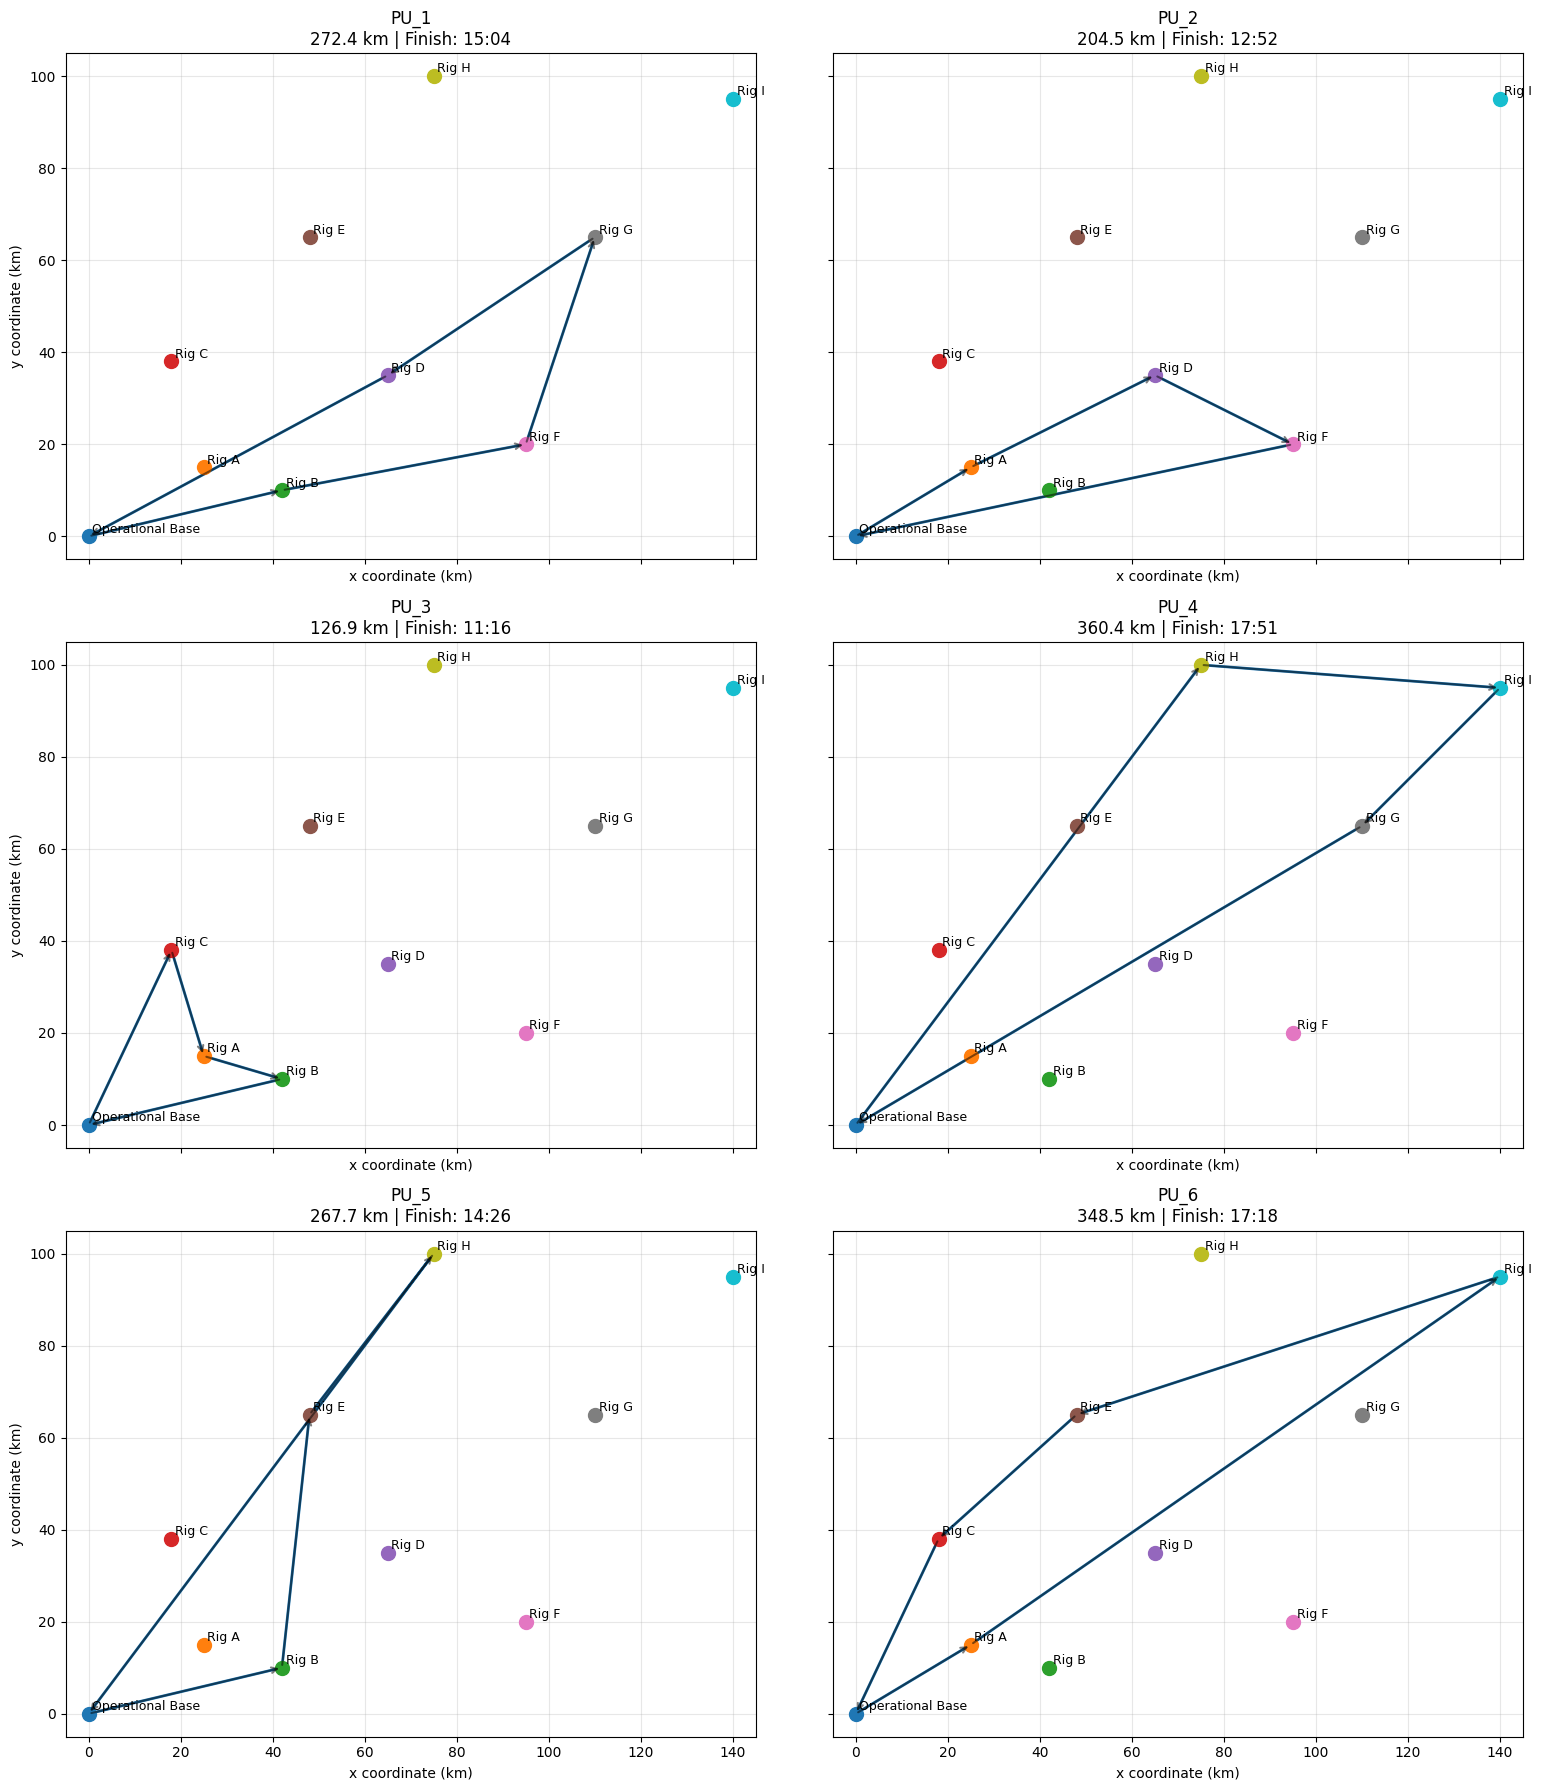

In [41]:
vehicle_ids = list(best_solution.routes)

all_x = [loc["x_km"] for loc in coordinates.values()]
all_y = [loc["y_km"] for loc in coordinates.values()]

fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 18),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, k in zip(axes, vehicle_ids):
    route = best_solution.routes[k]
    evaluation = evaluate_route(k, tuple(route))

    for loc in coordinates.values():
        ax.scatter(
            loc["x_km"],
            loc["y_km"],
            s=100,
            zorder=3
        )

        ax.text(
            loc["x_km"] + 0.8,
            loc["y_km"] + 0.8,
            loc["name"],
            fontsize=9
        )

    physical_locations = (
        [start_location[k]]
        + [node_location[node] for node in route]
        + [end_location[k]]
    )

    x_values = [
        coordinates[loc]["x_km"]
        for loc in physical_locations
    ]

    y_values = [
        coordinates[loc]["y_km"]
        for loc in physical_locations
    ]

    ax.plot(
        x_values,
        y_values,
        marker="o",
        linewidth=2,
        zorder=2
    )

    for x0, y0, x1, y1 in zip(
        x_values[:-1],
        y_values[:-1],
        x_values[1:],
        y_values[1:]
    ):
        if (x0, y0) != (x1, y1):
            ax.annotate(
                "",
                xy=(x1, y1),
                xytext=(x0, y0),
                arrowprops={
                    "arrowstyle": "->",
                    "alpha": 0.5,
                    "linewidth": 1.5
                }
            )

    ax.set_title(
        f"{k}\n"
        f"{evaluation['distance']:.1f} km | "
        f"Finish: {minutes_to_clock(evaluation['finish_time'])}"
    )

    ax.set_xlabel("x coordinate (km)")
    ax.set_xlim(min(all_x) - 5, max(all_x) + 5)
    ax.set_ylim(min(all_y) - 5, max(all_y) + 5)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

for ax in axes[len(vehicle_ids):]:
    ax.axis("off")

for ax in axes[::2]:
    ax.set_ylabel("y coordinate (km)")

plt.tight_layout()
plt.show()